In [1]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.fc1   = nn.Linear(16 * 7 * 7, 64)
        self.fc2   = nn.Linear(64, 10)
        self.pool  = nn.MaxPool2d(2)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)
model = TinyNet()
model.load_state_dict(torch.load('tinynet_baseline_v1.pth'))
model.eval()
print("Baseline model loaded!")




Baseline model loaded!


## MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_data = torchvision.datasets.MNIST('./data', train=False,
                                        transform=transform, download=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [3]:
def load_fresh_model():
    model = TinyNet()
    model.load_state_dict(torch.load('tinynet_baseline_v1.pth'))
    model.eval()
    return model
def evaluate(model, test_loader):
    model.eval()
    correct = 0 
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            output = model(images)
            _,predicted = torch.max(output,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100* correct/total
    print(f"Accuracy: {accuracy:.2f}%")
    return accuracy
sanity_check_model = load_fresh_model()
evaluate(sanity_check_model, test_loader)

Accuracy: 98.77%


98.77

In [4]:
def prune_model(model, amount):
    prune.l1_unstructured(model.conv1, name='weight', amount=amount)
    prune.l1_unstructured(model.conv2, name='weight', amount=amount)
    prune.l1_unstructured(model.fc1, name='weight', amount=amount)
    prune.l1_unstructured(model.fc2, name='weight', amount=amount)
    return model
for amount in [0.60, 0.65, 0.66, 0.67, 0.70]:
    model = load_fresh_model()
    model = prune_model(model, amount)
    print(f"Sparsity: {int(amount*100)}%", end=" | ")
    evaluate(model, test_loader)

Sparsity: 60% | Accuracy: 96.99%
Sparsity: 65% | Accuracy: 95.01%
Sparsity: 66% | Accuracy: 94.05%
Sparsity: 67% | Accuracy: 91.34%
Sparsity: 70% | Accuracy: 86.77%


# PRUNING ONE LAYER,LEAVING REST ALONE

In [5]:

def prune_single_layer(layer_name,amount):
    model = load_fresh_model()
    layer = getattr(model,layer_name)
    prune.l1_unstructured(layer, name ='weight', amount=amount)
    acc  =evaluate(model,test_loader)
    return acc


In [6]:
for layer_name in ['conv1','conv2','fc1','fc2']:
    acc  = prune_single_layer(layer_name,0.70)
    print(f"{layer_name}: {acc:.2f}%")


Accuracy: 98.46%
conv1: 98.46%
Accuracy: 97.98%
conv2: 97.98%
Accuracy: 98.68%
fc1: 98.68%
Accuracy: 97.03%
fc2: 97.03%


In [7]:
check_points = [0.60,0.61,0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.70,0.71,0.72,0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.80]
results = {
    'conv1':[],
    'conv2':[],
    'fc1':[],
    'fc2':[]

}
for amount in check_points:
    for layer_name in results:
        acc = prune_single_layer(layer_name,amount)
        results[layer_name].append(acc)
        print(f"{layer_name} @ {int(amount*100)}%: {acc:.2f}%")
    print(f"--- Checkpoint {int(amount*100)}% done ---")



Accuracy: 98.67%
conv1 @ 60%: 98.67%
Accuracy: 98.37%
conv2 @ 60%: 98.37%
Accuracy: 98.73%
fc1 @ 60%: 98.73%
Accuracy: 98.10%
fc2 @ 60%: 98.10%
--- Checkpoint 60% done ---
Accuracy: 98.62%
conv1 @ 61%: 98.62%
Accuracy: 98.36%
conv2 @ 61%: 98.36%
Accuracy: 98.73%
fc1 @ 61%: 98.73%
Accuracy: 97.99%
fc2 @ 61%: 97.99%
--- Checkpoint 61% done ---
Accuracy: 98.65%
conv1 @ 62%: 98.65%
Accuracy: 98.23%
conv2 @ 62%: 98.23%
Accuracy: 98.75%
fc1 @ 62%: 98.75%
Accuracy: 98.01%
fc2 @ 62%: 98.01%
--- Checkpoint 62% done ---
Accuracy: 98.65%
conv1 @ 63%: 98.65%
Accuracy: 98.27%
conv2 @ 63%: 98.27%
Accuracy: 98.72%
fc1 @ 63%: 98.72%
Accuracy: 97.98%
fc2 @ 63%: 97.98%
--- Checkpoint 63% done ---
Accuracy: 98.63%
conv1 @ 64%: 98.63%
Accuracy: 98.26%
conv2 @ 64%: 98.26%
Accuracy: 98.75%
fc1 @ 64%: 98.75%
Accuracy: 98.14%
fc2 @ 64%: 98.14%
--- Checkpoint 64% done ---
Accuracy: 98.56%
conv1 @ 65%: 98.56%
Accuracy: 98.31%
conv2 @ 65%: 98.31%
Accuracy: 98.77%
fc1 @ 65%: 98.77%
Accuracy: 98.10%
fc2 @ 65%: 98.

In [8]:
print("CONV1")
print(results['conv1'])
print("CONV2")
print(results['conv2'])
print("fc1")
print(results['fc1'])
print("fc2")
print(results['fc2'])

CONV1
[98.67, 98.62, 98.65, 98.65, 98.63, 98.56, 98.4, 98.4, 98.42, 98.46, 98.46, 98.4, 98.19, 97.55, 97.55, 97.49, 96.5, 96.5, 97.22, 91.98, 85.52]
CONV2
[98.37, 98.36, 98.23, 98.27, 98.26, 98.31, 98.32, 98.29, 98.2, 98.09, 97.98, 97.94, 97.95, 97.83, 97.68, 97.44, 97.19, 97.37, 96.74, 96.3, 95.23]
fc1
[98.73, 98.73, 98.75, 98.72, 98.75, 98.77, 98.79, 98.78, 98.75, 98.72, 98.68, 98.69, 98.69, 98.73, 98.66, 98.64, 98.56, 98.58, 98.63, 98.6, 98.62]
fc2
[98.1, 97.99, 98.01, 97.98, 98.14, 98.1, 97.93, 97.55, 97.47, 97.11, 97.03, 96.41, 95.27, 95.01, 93.74, 93.43, 94.53, 94.73, 92.23, 87.54, 83.05]


In [9]:
gaps = []
for i in range(len(check_points)):
    accs_at_checkpoint = [results[layer][i] for layer in results]
    gap = max(accs_at_checkpoint) - min(accs_at_checkpoint)
    gaps.append(gap)
    print(max(accs_at_checkpoint), min(accs_at_checkpoint))
    print('gap', gap)


98.73 98.1
gap 0.6300000000000097
98.73 97.99
gap 0.7400000000000091
98.75 98.01
gap 0.7399999999999949
98.72 97.98
gap 0.7399999999999949
98.75 98.14
gap 0.6099999999999994
98.77 98.1
gap 0.6700000000000017
98.79 97.93
gap 0.8599999999999994
98.78 97.55
gap 1.230000000000004
98.75 97.47
gap 1.2800000000000011
98.72 97.11
gap 1.6099999999999994
98.68 97.03
gap 1.6500000000000057
98.69 96.41
gap 2.280000000000001
98.69 95.27
gap 3.4200000000000017
98.73 95.01
gap 3.719999999999999
98.66 93.74
gap 4.920000000000002
98.64 93.43
gap 5.209999999999994
98.56 94.53
gap 4.030000000000001
98.58 94.73
gap 3.8499999999999943
98.63 92.23
gap 6.3999999999999915
98.6 87.54
gap 11.059999999999988
98.62 83.05
gap 15.570000000000007


## FASHION MNIST


In [18]:
fashion_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

fashion_test_data = torchvision.datasets.FashionMNIST('./data', train=False,
                                                        transform=fashion_transform, download=True)
fashion_test_loader = DataLoader(fashion_test_data, batch_size=64, shuffle=False)

def load_fresh_fashion_model():
    model = TinyNet()
    model.load_state_dict(torch.load('tinynet_fashion_baseline.pth'))
    model.eval()
    return model

In [19]:
for amount in [0.20, 0.40, 0.60, 0.65, 0.70, 0.80]:
    model = load_fresh_fashion_model()
    model = prune_model(model, amount)
    print(f"Sparsity: {int(amount*100)}%", end=" | ")
    evaluate(model, fashion_test_loader)


Sparsity: 20% | Accuracy: 89.26%
Sparsity: 40% | Accuracy: 86.02%
Sparsity: 60% | Accuracy: 75.35%
Sparsity: 65% | Accuracy: 70.02%
Sparsity: 70% | Accuracy: 66.37%
Sparsity: 80% | Accuracy: 33.16%


In [20]:
for amount in [0.70,0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79,0.80]:
    model = load_fresh_fashion_model()
    model = prune_model(model, amount)
    print(f"Sparsity: {int(amount*100)}%", end=" | ")
    evaluate(model, fashion_test_loader)

Sparsity: 70% | Accuracy: 66.37%
Sparsity: 71% | Accuracy: 62.10%
Sparsity: 72% | Accuracy: 64.08%
Sparsity: 73% | Accuracy: 61.82%
Sparsity: 74% | Accuracy: 62.76%
Sparsity: 75% | Accuracy: 64.06%
Sparsity: 76% | Accuracy: 59.17%
Sparsity: 77% | Accuracy: 56.01%
Sparsity: 78% | Accuracy: 49.65%
Sparsity: 79% | Accuracy: 54.77%
Sparsity: 80% | Accuracy: 33.16%


In [21]:
for amount in [0.790, 0.792, 0.794, 0.796, 0.798,0.799, 0.800]:
    model = load_fresh_fashion_model()
    model = prune_model(model, amount)
    print(f"Sparsity: {amount*100:.1f}%", end=" | ")
    evaluate(model, fashion_test_loader)

Sparsity: 79.0% | Accuracy: 54.77%
Sparsity: 79.2% | Accuracy: 54.05%
Sparsity: 79.4% | Accuracy: 53.67%
Sparsity: 79.6% | Accuracy: 52.92%
Sparsity: 79.8% | Accuracy: 49.91%
Sparsity: 79.9% | Accuracy: 41.32%
Sparsity: 80.0% | Accuracy: 33.16%


In [22]:
for amount in [0.80,0.82,0.84,0.86,0.88,0.90]:
    model = load_fresh_fashion_model()
    model = prune_model(model, amount)
    print(f"Sparsity: {int(amount*100)}%", end=" | ")
    evaluate(model, fashion_test_loader)

Sparsity: 80% | Accuracy: 33.16%
Sparsity: 82% | Accuracy: 29.47%
Sparsity: 84% | Accuracy: 20.01%
Sparsity: 86% | Accuracy: 10.37%
Sparsity: 88% | Accuracy: 9.91%
Sparsity: 90% | Accuracy: 8.37%


In [23]:
for amount in [0.842,0.844,0.846,0.848,0.85]:
    model = load_fresh_fashion_model()
    model = prune_model(model, amount)
    print(f"Sparsity: {amount*100:.1f}%", end=" | ")
    evaluate(model, fashion_test_loader)

Sparsity: 84.2% | Accuracy: 12.55%
Sparsity: 84.4% | Accuracy: 12.80%
Sparsity: 84.6% | Accuracy: 12.07%
Sparsity: 84.8% | Accuracy: 11.66%
Sparsity: 85.0% | Accuracy: 11.62%


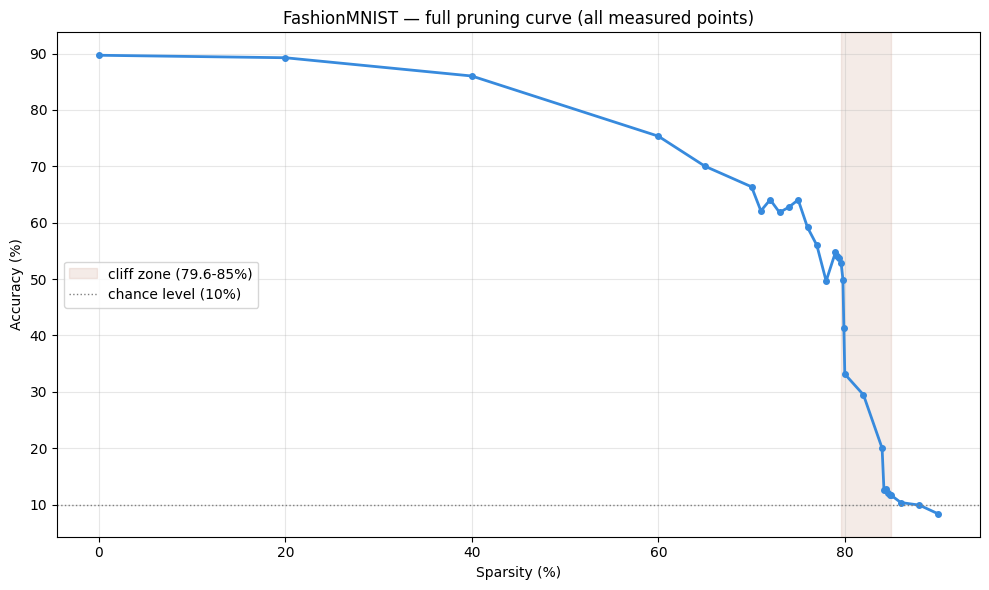

In [24]:
import matplotlib.pyplot as plt

sparsity_pct = [0, 20, 40, 60, 65, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79,
                79.2, 79.4, 79.6, 79.8, 79.9, 80.0, 82, 84, 84.2, 84.4,
                84.6, 84.8, 85.0, 86, 88, 90]
accuracy = [89.70, 89.26, 86.02, 75.35, 70.02, 66.37, 62.10, 64.08, 61.82,
            62.76, 64.06, 59.17, 56.01, 49.65, 54.77, 54.05, 53.67, 52.92,
            49.91, 41.32, 33.16, 29.47, 20.01, 12.55, 12.80, 12.07, 11.66,
            11.62, 10.37, 9.91, 8.37]

plt.figure(figsize=(10, 6))
plt.plot(sparsity_pct, accuracy, marker='o', color='#378ADD', linewidth=2, markersize=4)

plt.axvspan(79.6, 85, color='#993C1D', alpha=0.10, label='cliff zone (79.6-85%)')
plt.axhline(10, color='gray', linestyle=':', linewidth=1, label='chance level (10%)')

plt.xlabel('Sparsity (%)')
plt.ylabel('Accuracy (%)')
plt.title('FashionMNIST — full pruning curve (all measured points)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fashionmnist_full_pruning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
checkpoints_fashion = [0.00, 0.10, 0.20, 0.30, 0.40,
                       0.79, 0.80, 0.81, 0.82, 0.83, 0.84, 0.85]

In [26]:
results_fashion = {
    'conv1': [],
    'conv2': [],
    'fc1':   [],
    'fc2':   []
}

def prune_single_layer_fashion(layer_name, amount):
    model = load_fresh_fashion_model()
    layer = getattr(model, layer_name)
    prune.l1_unstructured(layer, name='weight', amount=amount)
    acc = evaluate(model, fashion_test_loader)
    return acc

for amount in checkpoints_fashion:
    for layer_name in results_fashion:
        acc = prune_single_layer_fashion(layer_name, amount)
        results_fashion[layer_name].append(acc)
        print(f"{layer_name} @ {amount*100:.0f}%: {acc:.2f}%")
    print(f"--- Checkpoint {amount*100:.0f}% done ---")

Accuracy: 89.06%
conv1 @ 0%: 89.06%
Accuracy: 89.06%
conv2 @ 0%: 89.06%
Accuracy: 89.06%
fc1 @ 0%: 89.06%
Accuracy: 89.06%
fc2 @ 0%: 89.06%
--- Checkpoint 0% done ---
Accuracy: 88.96%
conv1 @ 10%: 88.96%
Accuracy: 89.06%
conv2 @ 10%: 89.06%
Accuracy: 88.99%
fc1 @ 10%: 88.99%
Accuracy: 88.80%
fc2 @ 10%: 88.80%
--- Checkpoint 10% done ---
Accuracy: 88.99%
conv1 @ 20%: 88.99%
Accuracy: 89.25%
conv2 @ 20%: 89.25%
Accuracy: 89.04%
fc1 @ 20%: 89.04%
Accuracy: 89.12%
fc2 @ 20%: 89.12%
--- Checkpoint 20% done ---
Accuracy: 87.65%
conv1 @ 30%: 87.65%
Accuracy: 89.06%
conv2 @ 30%: 89.06%
Accuracy: 89.18%
fc1 @ 30%: 89.18%
Accuracy: 88.59%
fc2 @ 30%: 88.59%
--- Checkpoint 30% done ---
Accuracy: 87.49%
conv1 @ 40%: 87.49%
Accuracy: 88.95%
conv2 @ 40%: 88.95%
Accuracy: 89.38%
fc1 @ 40%: 89.38%
Accuracy: 87.45%
fc2 @ 40%: 87.45%
--- Checkpoint 40% done ---
Accuracy: 84.74%
conv1 @ 79%: 84.74%
Accuracy: 73.08%
conv2 @ 79%: 73.08%
Accuracy: 86.82%
fc1 @ 79%: 86.82%
Accuracy: 81.67%
fc2 @ 79%: 81.67%
-

In [27]:
print("CONV1")
print(results_fashion['conv1'])
print("CONV2")
print(results_fashion['conv2'])
print("fc1")
print(results_fashion['fc1'])
print("fc2")
print(results_fashion['fc2'])

CONV1
[89.06, 88.96, 88.99, 87.65, 87.49, 84.74, 73.94, 73.94, 53.68, 36.23, 36.23, 22.48]
CONV2
[89.06, 89.06, 89.25, 89.06, 88.95, 73.08, 72.28, 74.33, 72.32, 71.67, 71.12, 68.53]
fc1
[89.06, 88.99, 89.04, 89.18, 89.38, 86.82, 86.15, 86.39, 85.76, 84.04, 83.09, 83.42]
fc2
[89.06, 88.8, 89.12, 88.59, 87.45, 81.67, 79.86, 79.75, 79.05, 81.03, 79.88, 68.77]


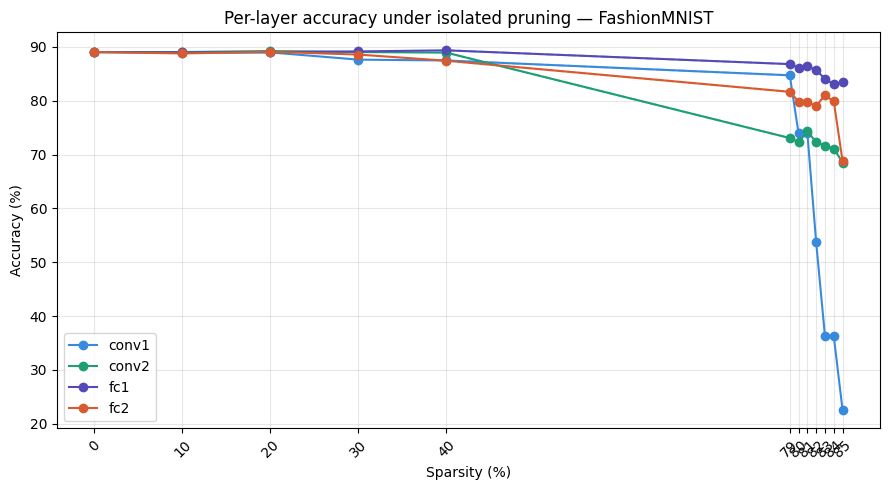

In [28]:
import matplotlib.pyplot as plt

sparsity_fashion = [0, 10, 20, 30, 40, 79, 80, 81, 82, 83, 84, 85]

results_fashion_manual = {
    'conv1': [89.06, 88.96, 88.99, 87.65, 87.49, 84.74, 73.94, 73.94, 53.68, 36.23, 36.23, 22.48],
    'conv2': [89.06, 89.06, 89.25, 89.06, 88.95, 73.08, 72.28, 74.33, 72.32, 71.67, 71.12, 68.53],
    'fc1':   [89.06, 88.99, 89.04, 89.18, 89.38, 86.82, 86.15, 86.39, 85.76, 84.04, 83.09, 83.42],
    'fc2':   [89.06, 88.80, 89.12, 88.59, 87.45, 81.67, 79.86, 79.75, 79.05, 81.03, 79.88, 68.77]
}

colors = {'conv1': '#378ADD', 'conv2': '#1D9E75', 'fc1': '#534AB7', 'fc2': '#D85A30'}

plt.figure(figsize=(9, 5))
for layer in results_fashion_manual:
    plt.plot(sparsity_fashion, results_fashion_manual[layer], marker='o', label=layer, color=colors[layer])

# Dashed line across the untested 41-78% stretch, drawn separately for each layer
for layer in results_fashion_manual:
    plt.plot([40, 79], [results_fashion_manual[layer][4], results_fashion_manual[layer][5]],
              linestyle='--', color=colors[layer], alpha=0.4)

plt.xticks(sparsity_fashion, rotation=45)
plt.xlabel('Sparsity (%)')
plt.ylabel('Accuracy (%)')
plt.title('Per-layer accuracy under isolated pruning — FashionMNIST')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('layer_sensitivity_raw_fashion.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
gaps_fashion = []
for i in range(len(checkpoints_fashion)):
    row = [results_fashion[layer][i] for layer in results_fashion]
    gap = max(row) - min(row)
    gaps_fashion.append(gap)

print(gaps_fashion)


[0.0, 0.2600000000000051, 0.2600000000000051, 1.5300000000000011, 1.9299999999999926, 13.739999999999995, 13.870000000000005, 12.450000000000003, 32.080000000000005, 47.81000000000001, 46.86000000000001, 60.94]


In [37]:
checkpoints_fashion_gapfill = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70,
                                0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78]

results_fashion_gapfill = {
    'conv1': [],
    'conv2': [],
    'fc1':   [],
    'fc2':   []
}

for amount in checkpoints_fashion_gapfill:
    for layer_name in results_fashion_gapfill:
        acc = prune_single_layer_fashion(layer_name, amount)
        results_fashion_gapfill[layer_name].append(acc)
        print(f"{layer_name} @ {amount*100:.0f}%: {acc:.2f}%")
    print(f"--- Checkpoint {amount*100:.0f}% done ---")

Accuracy: 87.57%
conv1 @ 45%: 87.57%
Accuracy: 88.15%
conv2 @ 45%: 88.15%
Accuracy: 89.32%
fc1 @ 45%: 89.32%
Accuracy: 87.75%
fc2 @ 45%: 87.75%
--- Checkpoint 45% done ---
Accuracy: 87.10%
conv1 @ 50%: 87.10%
Accuracy: 88.22%
conv2 @ 50%: 88.22%
Accuracy: 89.23%
fc1 @ 50%: 89.23%
Accuracy: 88.38%
fc2 @ 50%: 88.38%
--- Checkpoint 50% done ---
Accuracy: 84.52%
conv1 @ 55%: 84.52%
Accuracy: 86.32%
conv2 @ 55%: 86.32%
Accuracy: 89.34%
fc1 @ 55%: 89.34%
Accuracy: 88.34%
fc2 @ 55%: 88.34%
--- Checkpoint 55% done ---
Accuracy: 83.78%
conv1 @ 60%: 83.78%
Accuracy: 85.53%
conv2 @ 60%: 85.53%
Accuracy: 89.12%
fc1 @ 60%: 89.12%
Accuracy: 87.45%
fc2 @ 60%: 87.45%
--- Checkpoint 60% done ---
Accuracy: 82.59%
conv1 @ 65%: 82.59%
Accuracy: 84.08%
conv2 @ 65%: 84.08%
Accuracy: 88.89%
fc1 @ 65%: 88.89%
Accuracy: 84.66%
fc2 @ 65%: 84.66%
--- Checkpoint 65% done ---
Accuracy: 78.22%
conv1 @ 70%: 78.22%
Accuracy: 82.80%
conv2 @ 70%: 82.80%
Accuracy: 88.45%
fc1 @ 70%: 88.45%
Accuracy: 87.25%
fc2 @ 70%: 87.

In [39]:
print("CONV1")
print(results_fashion_gapfill['conv1'])
print("CONV2")
print(results_fashion_gapfill['conv2'])
print("fc1")
print(results_fashion_gapfill['fc1'])
print("fc2")
print(results_fashion_gapfill['fc2'])

CONV1
[87.57, 87.1, 84.52, 83.78, 82.59, 78.22, 73.17, 79.66, 80.42, 80.42, 84.0, 83.6, 83.6, 83.39]
CONV2
[88.15, 88.22, 86.32, 85.53, 84.08, 82.8, 81.26, 81.39, 79.43, 78.22, 77.62, 77.73, 75.8, 73.46]
fc1
[89.32, 89.23, 89.34, 89.12, 88.89, 88.45, 88.51, 88.27, 88.14, 88.03, 87.76, 87.64, 87.33, 86.89]
fc2
[87.75, 88.38, 88.34, 87.45, 84.66, 87.25, 85.55, 84.13, 83.42, 83.31, 83.33, 82.02, 82.58, 81.27]


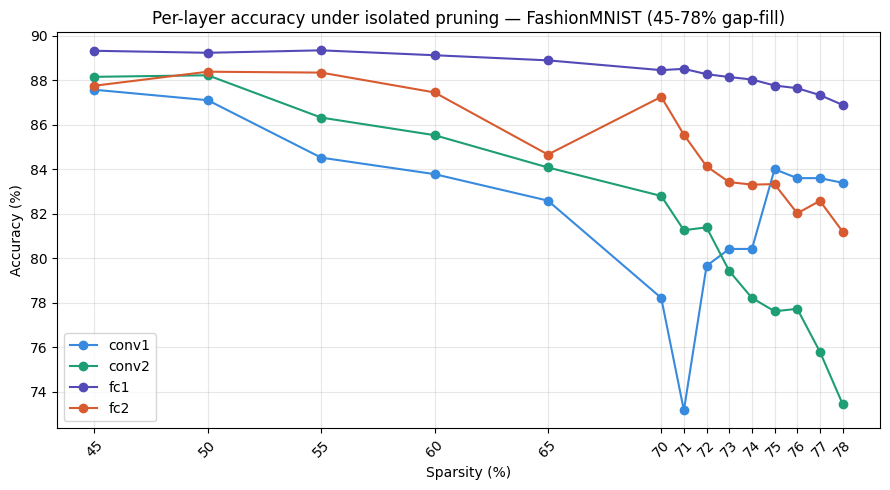

In [40]:
import matplotlib.pyplot as plt

sparsity_gapfill = [45, 50, 55, 60, 65, 70, 71, 72, 73, 74, 75, 76, 77, 78]

results_gapfill_manual = {
    'conv1': [87.57, 87.10, 84.52, 83.78, 82.59, 78.22, 73.17, 79.66, 80.42, 80.42, 84.00, 83.60, 83.60, 83.39],
    'conv2': [88.15, 88.22, 86.32, 85.53, 84.08, 82.80, 81.26, 81.39, 79.43, 78.22, 77.62, 77.73, 75.80, 73.46],
    'fc1':   [89.32, 89.23, 89.34, 89.12, 88.89, 88.45, 88.51, 88.27, 88.14, 88.03, 87.76, 87.64, 87.33, 86.89],
    'fc2':   [87.75, 88.38, 88.34, 87.45, 84.66, 87.25, 85.55, 84.13, 83.42, 83.31, 83.33, 82.02, 82.58, 81.20]
}

colors = {'conv1': '#378ADD', 'conv2': '#1D9E75', 'fc1': '#534AB7', 'fc2': '#D85A30'}

plt.figure(figsize=(9, 5))
for layer in results_gapfill_manual:
    plt.plot(sparsity_gapfill, results_gapfill_manual[layer], marker='o', label=layer, color=colors[layer])

plt.xticks(sparsity_gapfill, rotation=45)
plt.xlabel('Sparsity (%)')
plt.ylabel('Accuracy (%)')
plt.title('Per-layer accuracy under isolated pruning — FashionMNIST (45-78% gap-fill)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('layer_sensitivity_raw_fashion_gapfill.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
checkpoints_fashion_full = [0.00,0.10,0.20,0.30,0.40,0.45,0.50,0.55,0.60,0.65,
                             0.70,0.71,0.72,0.73,0.74,0.75,0.76,0.77,0.78,
                             0.79,0.80,0.81,0.82,0.83,0.84,0.85]

results_fashion_full = {}
for layer in results_fashion:
    baseline  = results_fashion[layer][0:5]    # your original 0,10,20,30,40
    cliffzone = results_fashion[layer][5:12]   # your original 79-85
    gapfill   = results_fashion_gapfill[layer] # tonight's new 45-78
    results_fashion_full[layer] = baseline + gapfill + cliffzone

gaps_fashion_full = []
for i in range(len(checkpoints_fashion_full)):
    row = [results_fashion_full[layer][i] for layer in results_fashion_full]
    gaps_fashion_full.append(max(row) - min(row))
checkpoints_fashion_full_pct = [c * 100 for c in checkpoints_fashion_full]

In [42]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=checkpoints_fashion_full_pct,
    y=gaps_fashion_full,
    mode='lines+markers',
    line=dict(color='#D85A30', width=2),
    marker=dict(size=7),
    hovertemplate='Sparsity: %{x}%<br>Gap: %{y:.2f}<extra></extra>'
))

fig.add_vrect(x0=0, x1=40, fillcolor='gray', opacity=0.12, line_width=0,
              annotation_text='baseline (0-40%)', annotation_position='top left')

fig.add_vline(x=52, line_dash='dash', line_color='#1D9E75',
              annotation_text='departs baseline (~50-55%)', annotation_position='top')

fig.add_vline(x=79.6, line_dash='dash', line_color='#993C1D',
              annotation_text='confirmed cliff (79.6%)', annotation_position='top right')

fig.update_xaxes(dtick=5, tick0=0, title_text='Sparsity (%)')
fig.update_yaxes(title_text='Sensitivity gap (percentage points)')

fig.update_layout(
    title='Layer sensitivity gap vs. sparsity — FashionMNIST (full)',
    template='plotly_white'
)

fig.show()